#### Versuch exact matching zu evaluieren

In [1]:
import os
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [13]:
def read_file(file_path):
    with open(file_path, 'r', encoding="utf-8") as file:
        return file.read()

def extract_nct_number(filename):
    match = re.search(r'NCT\d+', filename)
    return match.group() if match else None

def extract_operators(text):
    operators = re.findall(r'\[(AND|OR|NOT)\]', text)
    return operators

def find_operator_words(text, operators):
    words = {op: [] for op in operators}
    word_list = text.split()
    for i, word in enumerate(word_list):
        if word in ["[AND]", "[OR]", "[NOT]"]:
            operator = word[1:-1]
            if operator == 'NOT' and i + 1 < len(word_list):
                words[operator].append(word_list[i + 1])
            elif operator in ['AND', 'OR'] and i - 1 >= 0:
                prev_word = re.sub(r'[^\w]', '', word_list[i - 1])  # Entferne Satzzeichen
                words[operator].append(prev_word)
    return words

def compare_operators(label_text, model_text, operator):
    label_operators = extract_operators(label_text)
    model_operators = extract_operators(model_text)

    label_words_dict = find_operator_words(label_text, label_operators)
    model_words_dict = find_operator_words(model_text, model_operators)

    label_words = label_words_dict.get(operator, [])
    model_words = model_words_dict.get(operator, [])

    tp = sum(1 for word in label_words if word in model_words)
    fp = sum(1 for word in model_words if word not in label_words)
    fn = sum(1 for word in label_words if word not in model_words)

    return tp, fp, fn, len(label_words), len(model_words)

def calculate_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0
    accuracy = tp / (tp + fn) if tp + fn > 0 else 0
    return precision, recall, f1, accuracy

def evaluate_models(label_folder, model_folder):
    operators = ['AND', 'OR', 'NOT']
    metrics = {op: {'tp': 0, 'fp': 0, 'fn': 0, 'label_count': 0, 'model_count': 0, 'correct_count': 0, 'correct_ncts': []} for op in operators}
    processed_label_files = 0

    for model_file in os.listdir(model_folder):
        if model_file.endswith('.txt'):
            nct_number = extract_nct_number(model_file)

            if nct_number:
                label_file_path = os.path.join(label_folder, f'{nct_number}.txt')
                model_file_path = os.path.join(model_folder, model_file)

                if os.path.exists(label_file_path):
                    processed_label_files += 1
                    label_text = read_file(label_file_path)
                    model_text = read_file(model_file_path)

                    for op in operators:
                        tp, fp, fn, label_count, model_count = compare_operators(label_text, model_text, op)

                        metrics[op]['tp'] += tp
                        metrics[op]['fp'] += fp
                        metrics[op]['fn'] += fn
                        metrics[op]['label_count'] += label_count
                        metrics[op]['model_count'] += model_count
                        metrics[op]['correct_count'] += tp

                        if tp > 0:
                            metrics[op]['correct_ncts'].append(nct_number)
    results = {}
    #print(f"Total processed label files: {processed_label_files}")
    for op in operators:
        precision, recall, f1, accuracy = calculate_metrics(metrics[op]['tp'], metrics[op]['fp'], metrics[op]['fn'])
        #print(f"{op}:")
        #print(f"  Precision: {precision:.3f}")
        #print(f"  Recall: {recall:.3f}")
        #print(f"  F1-score: {f1:.3f}")
        #print(f"  Accuracy: {accuracy:.3f}")
        #print(f"  Total in Label: {metrics[op]['label_count']}")
        #print(f"  Total in Model: {metrics[op]['model_count']}")
        #print(f"  Correctly Identified: {metrics[op]['correct_count']}")
        #print(f"  Correct NCTs: {metrics[op]['correct_ncts']}\n")
        results[op] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy,
            'total_label': metrics[op]['label_count'],
            'total_model': metrics[op]['model_count'],
            'correct_count': metrics[op]['correct_count']
        }
    
    return results


In [14]:
label_folder = '../../input/lct_p1'
model_folder = 'model_output/Llama-3-70B-Instruct_4_shot/output'

evaluate_models(label_folder, model_folder)

{'AND': {'precision': 0.1510344827586207,
  'recall': 0.2673992673992674,
  'f1': 0.19303657999118556,
  'accuracy': 0.2673992673992674,
  'total_label': 819,
  'total_model': 1454,
  'correct_count': 219},
 'OR': {'precision': 0.6834701055099648,
  'recall': 0.5615217914760414,
  'f1': 0.6165234633179114,
  'accuracy': 0.5615217914760414,
  'total_label': 4153,
  'total_model': 3380,
  'correct_count': 2332},
 'NOT': {'precision': 0.027149321266968326,
  'recall': 0.013015184381778741,
  'f1': 0.01759530791788856,
  'accuracy': 0.013015184381778741,
  'total_label': 922,
  'total_model': 441,
  'correct_count': 12}}

In [15]:
## Baue 5 shot auf 
# NCT03865433.txt
# NCT03860324.txt
# NCT03860233.txt
# NCT03923231.txt
# NCT03930121.txt
shot_list = [
    "NCT03865433.txt",
    "NCT03860324.txt",
    "NCT03860233.txt",
    "NCT03923231.txt",
    "NCT03930121.txt"
]


In [16]:

label_folder = '../../input/lct_p1'
model_output_folder = 'model_output'

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]
#models = ['Llama-3-70B-Instruct_4_shot', 'Llama-3-8B-Instruct_4_shot']

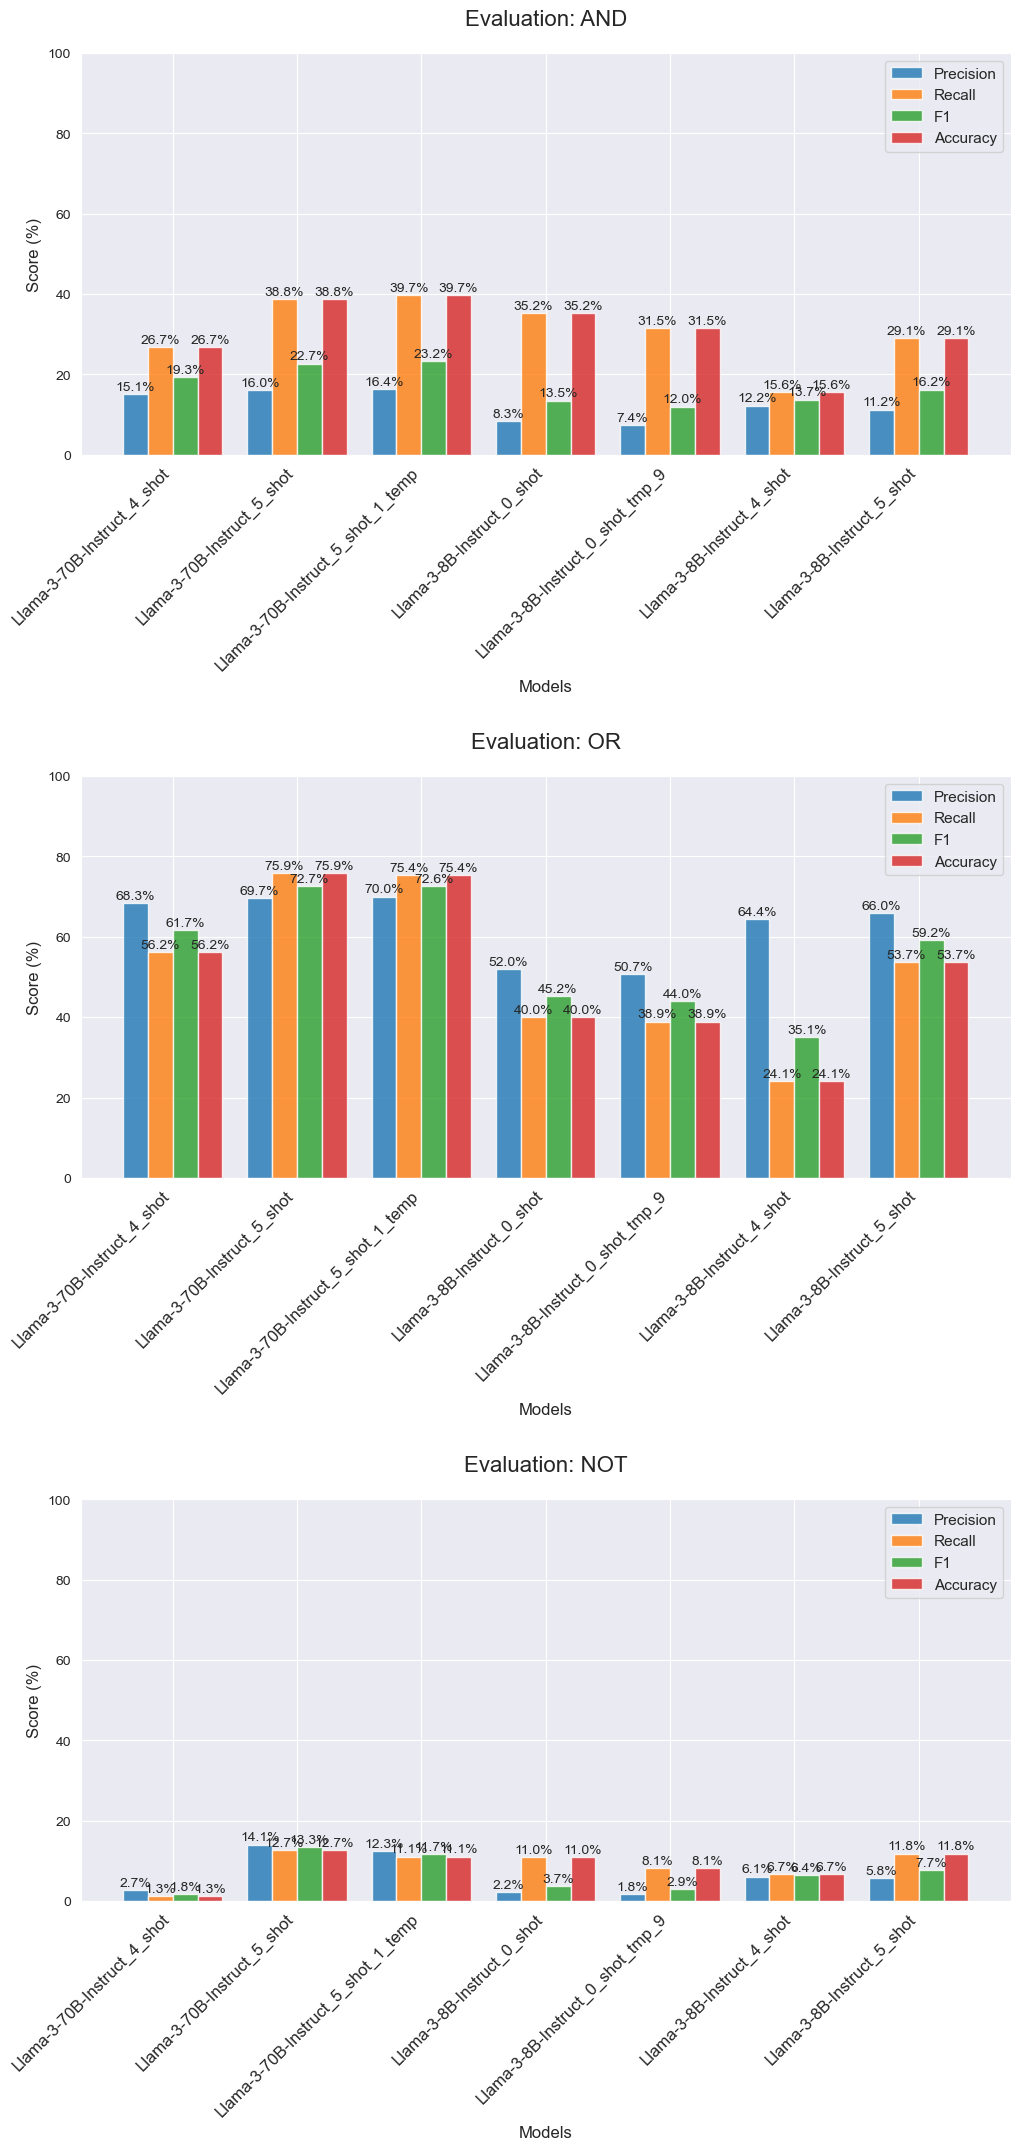

In [20]:
all_metrics = {}

for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder)

    # Umrechnung der Werte in Prozent
    for op in metrics:
        for metric in metrics[op]:
            metrics[op][metric] *= 100

    all_metrics[model] = metrics

# Plotting the metrics
operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1', 'accuracy']

fig, axs = plt.subplots(len(operators), 1, figsize=(12, 24), gridspec_kw={'hspace': 0.8})

for i, op in enumerate(operators):
    ax = axs[i]

    model_names = []
    metric_values = {metric: [] for metric in metrics_to_plot}

    for model, model_metrics in all_metrics.items():
        model_names.append(model)
        for metric in metrics_to_plot:
            metric_values[metric].append(model_metrics[op][metric])

    x = np.arange(len(model_names))
    bar_width = 0.2
    opacity = 0.8

    for j, metric in enumerate(metrics_to_plot):
        ax.bar(x + j * bar_width, metric_values[metric], bar_width, alpha=opacity, label=metric.capitalize())

    ax.set_xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=12)
    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_title(f'Evaluation: {op}', fontsize=16, pad=20)
    ax.legend(fontsize=11)
    ax.grid(True)

    for j, metric in enumerate(metrics_to_plot):
        for k, v in enumerate(metric_values[metric]):
            ax.text(k + j * bar_width, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.show()

In [37]:
def generate_latex_table(all_metrics, operators, metrics_to_plot):
    latex_table = "\\begin{table}[h]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{l" + "c" * (len(metrics_to_plot) * len(operators)) + "}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & " + " & ".join([f"\\multicolumn{{{len(metrics_to_plot)}}}{{c}}{{{op}}}" for op in operators]) + " \\\\\n"
    latex_table += "\\cmidrule(lr){2-" + str(len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(len(metrics_to_plot) + 2) + "-" + str(2 * len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(2 * len(metrics_to_plot) + 2) + "-" + str(3 * len(metrics_to_plot) + 1) + "}\n"
    latex_table += " & " + " & ".join([" & ".join(metric[:1].upper() for metric in metrics_to_plot) for _ in operators]) + " \\\\\n"
    latex_table += "\\midrule\n"

    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")  # Replace underscores with hyphens in the model name
        for op in operators:
            for metric in metrics_to_plot:
                row += " & {:.2f}".format(model_metrics[op][metric])
        row += " \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{Model Performance Metrics}\n"
    latex_table += "\\label{tab:model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True) 
    with open("latex/model_metrics_table.tex", "w") as file:
        file.write(latex_table)
    return latex_table

# Generate LaTeX table
latex_table = generate_latex_table(all_metrics, operators, metrics_to_plot)

print(latex_table)

\begin{table}[h]
\centering
\begin{tabular}{lcccccccccccc}
\toprule
Model & \multicolumn{4}{c}{AND} & \multicolumn{4}{c}{OR} & \multicolumn{4}{c}{NOT} \\
\cmidrule(lr){2-5}  \cmidrule(lr){6-9}  \cmidrule(lr){10-13}
 & P & R & F & A & P & R & F & A & P & R & F & A \\
\midrule
Llama-3-70B-Instruct-4-shot & 0.15 & 0.27 & 0.19 & 0.27 & 0.68 & 0.56 & 0.62 & 0.56 & 0.03 & 0.01 & 0.02 & 0.01 \\
Llama-3-8B-Instruct-4-shot & 0.12 & 0.16 & 0.14 & 0.16 & 0.64 & 0.24 & 0.35 & 0.24 & 0.06 & 0.07 & 0.06 & 0.07 \\
\bottomrule
\end{tabular}
\caption{Model Performance Metrics}
\label{tab:model_metrics}
\end{table}

